## *Customer Intelligence System*

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Country-data.csv")

print(df.head())


Saving Country-data.csv to Country-data (1).csv
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


## Data Cleaning

In [ ]:
df.columns = df.columns.str.strip()

df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("\nMissing Values")
print(df.isnull().sum())


Missing Values
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


/tmp/ipykernel_3701/496516458.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


## Feature Scaling

In [ ]:
countries = df['country']

X = df.drop('country', axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Data Shape:", X_scaled.shape)


Scaled Data Shape: (167, 9)


## Elbow Method

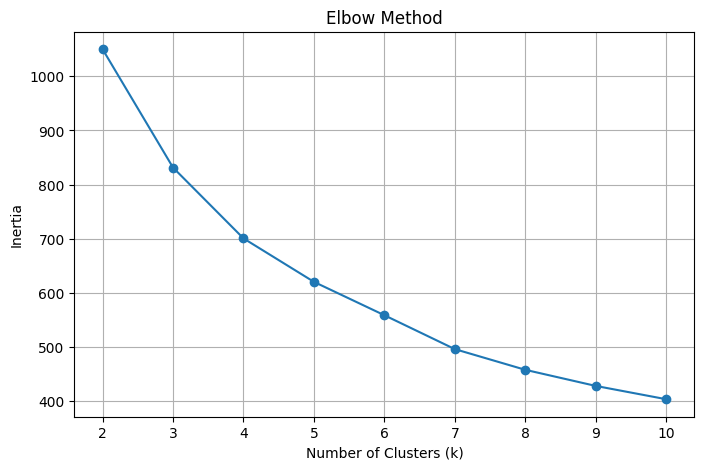

In [ ]:
inertia = []

K = range(2,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

## K-Means Clustering

In [ ]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels


## Silhouette Score

In [ ]:
score = silhouette_score(X_scaled, kmeans_labels)

print("="*50)
print("Silhouette Score :", round(score,3))
print("="*50)

Silhouette Score : 0.283


## DBSCAN Clustering

In [ ]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print("\nDBSCAN Cluster Counts")

print(df['DBSCAN_Cluster'].value_counts())


DBSCAN Cluster Counts
DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64


## PCA Visualization

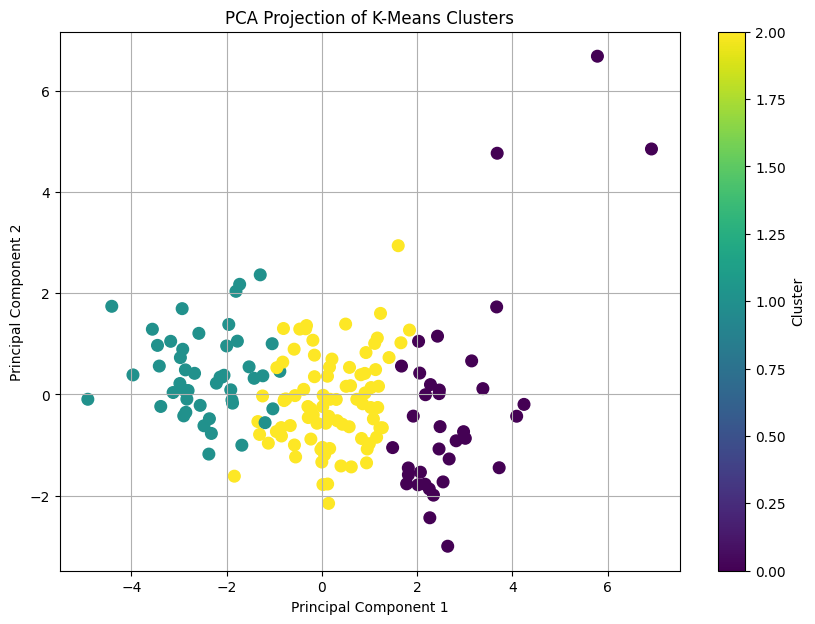

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,7))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap='viridis',
    s=70
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA Projection of K-Means Clusters")

plt.colorbar(scatter,label="Cluster")

plt.grid(True)

plt.show()

## Cluster Summary and Country Distribution

In [ ]:
cluster_summary = df.groupby("KMeans_Cluster").mean(numeric_only=True)

print("\nCluster Summary")

print(cluster_summary)

# ==========================================================
# Countries in each cluster
# ==========================================================

for i in range(best_k):

    print("\n")
    print("="*60)
    print("Cluster", i)
    print("="*60)

    print(df[df["KMeans_Cluster"]==i]["country"].tolist())


Cluster Summary
                child_mort    exports    health    imports        income  \
KMeans_Cluster                                                             
0                 5.000000  58.738889  8.807778  51.491667  45672.222222   
1                92.961702  29.151277  6.388511  42.323404   3942.404255   
2                21.927381  40.243917  6.200952  47.473404  12305.595238   

                inflation  life_expec  total_fer          gdpp  DBSCAN_Cluster  
KMeans_Cluster                                                                  
0                2.671250   80.127778   1.752778  42494.444444       -0.250000  
1               12.019681   59.187234   5.008085   1922.382979       -0.340426  
2                7.600905   72.814286   2.307500   6486.452381       -0.059524  


Cluster 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland', 'France', 'Germany', 'Greece', 'Iceland', 'Ireland', 'Israel', 'Ital

In [ ]:
df.to_csv("Customer_Intelligence_Output.csv", index=False)

print("\nOutput file saved successfully!")


Output file saved successfully!


# **Observations**

1. High-mortality countries are grouped together, indicating low socio-economic development.
2. Developed countries form a cluster with high income and long life expectancy.
3. Developing countries show moderate economic and health indicators.
4. PCA shows clear separation between clusters.
5. DBSCAN identifies dense clusters and potential outlier countries.